# Task 1 & 2: Load and Explore the Data

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB

--- Statistical Summary ---
       Avg. Session Length  Time on App  Time on Website  \
count           500.000000   500.000000       500.000000   
mean             33.053194    12.052488        37.060445   
std               0.992563     0.994216         1.010489   
min              29.532429     8.508152       

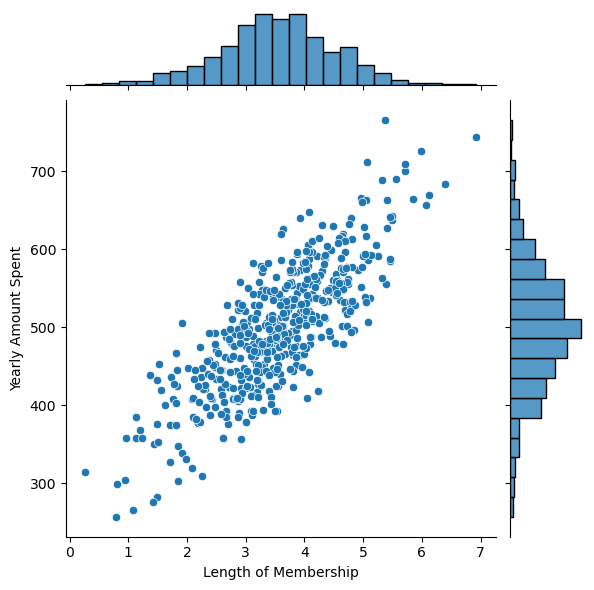

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset into a DataFrame
df = pd.read_csv("D:\download\Ecommerce Customers")

# 2. Explore the data (head, info, describe)
print("--- Data Info ---")
df.info()

print("\n--- Statistical Summary ---")
print(df.describe())

# Quick visualization to see the relationship between Membership Length and Amount Spent
sns.jointplot(x='Length of Membership', y='Yearly Amount Spent', data=df)
plt.show()

# Task 3 & 4: Data Cleaning & Feature Engineering

In [3]:
# 3 & 4. Isolate the numerical features we actually need for the model.
# We will drop 'Email', 'Address', and 'Avatar' as they don't provide numerical value for linear regression.
numerical_df = df[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership', 'Yearly Amount Spent']]

# Task 5: Prepare the Data for Modeling

In [4]:
from sklearn.model_selection import train_test_split

# Define Features (X) and Target (y)
X = numerical_df[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']]
y = numerical_df['Yearly Amount Spent']

# Split the data (e.g., 70% Training, 30% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

# Task 6: Train the Model

In [5]:
from sklearn.linear_model import LinearRegression

# Initialize and train the model
lm = LinearRegression()
lm.fit(X_train, y_train)

# Display the coefficients to see which feature has the biggest impact
coeff_df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
print("\nModel Coefficients:")
print(coeff_df)


Model Coefficients:
                      Coefficient
Avg. Session Length     25.981550
Time on App             38.590159
Time on Website          0.190405
Length of Membership    61.279097


# Task 7: Evaluate the Model Performance


Model Evaluation Metrics:
MAE (Mean Absolute Error): 7.2281486534308454
MSE (Mean Squared Error): 79.81305165097454
RMSE (Root Mean Squared Error): 8.933815066978639
R-squared (R2) Score: 0.9890046246741234


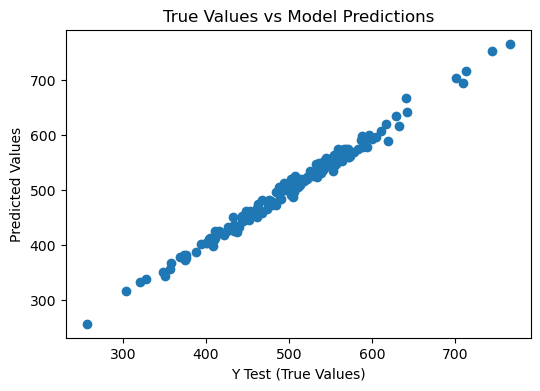

In [6]:
from sklearn import metrics

# Make predictions on the test set
predictions = lm.predict(X_test)

# Calculate and print evaluation metrics
print('\nModel Evaluation Metrics:')
print('MAE (Mean Absolute Error):', metrics.mean_absolute_error(y_test, predictions))
print('MSE (Mean Squared Error):', metrics.mean_squared_error(y_test, predictions))
print('RMSE (Root Mean Squared Error):', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

# R2 Score (Variance explained by the model)
print('R-squared (R2) Score:', metrics.r2_score(y_test, predictions))

# Visualizing the True Values vs. Predicted Values
plt.figure(figsize=(6,4))
plt.scatter(y_test, predictions)
plt.xlabel('Y Test (True Values)')
plt.ylabel('Predicted Values')
plt.title('True Values vs Model Predictions')
plt.show()